<a href="https://colab.research.google.com/github/Khoawawa/DeepLearning-HCMUT-ASS-MS/blob/main/ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import torch.nn as nn

In [19]:
batch_size = 64

In [20]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

IMAGENET_train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

IMAGENET_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

train_dataset_full = torchvision.datasets.CIFAR10(
    root="/content/data",
    train=True,
    download=True,
    transform=IMAGENET_train_transform
)

val_dataset_full = torchvision.datasets.CIFAR10(
    root="/content/data",
    train=True,
    download=False,
    transform=IMAGENET_test_transform
)

train_size = int(0.9 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

generator = torch.Generator().manual_seed(42)

indices = torch.randperm(len(train_dataset_full), generator=generator)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

trainset = Subset(train_dataset_full, train_indices)
valset = Subset(val_dataset_full, val_indices)

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)

# test dataset
testset = torchvision.datasets.CIFAR10(
    root="/content/data",
    train=False,
    download=True,
    transform=IMAGENET_test_transform
)

testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = (
    "airplane","automobile","bird","cat",
    "deer","dog","frog","horse","ship","truck"
)

In [31]:
from tqdm import tqdm
import torch
import copy

def train(model, trainloader, valloader, optimizer, criterion, device, num_epochs, patience=3):
    model.to(device)

    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        train_loop = tqdm(trainloader, leave=True)

        for inputs, labels in train_loop:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            train_loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
            train_loop.set_postfix(train_loss=loss.item())

        train_loss = running_loss / len(trainloader)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in valloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(valloader)
        val_acc = correct / total

        print(
            f"Epoch {epoch+1}: "
            f"Train Loss={train_loss:.4f} "
            f"Val Loss={val_loss:.4f} "
            f"Val Acc={val_acc:.4f}"
        )
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0

            torch.save(best_model_wts, "best_model.pth")

        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break
    # load best weights
    model.load_state_dict(best_model_wts)

    return model

In [32]:
def test(model, testloader, device):
  model.eval()
  model.to(device)

  correct = 0
  total = 0

  all_outputs = []
  all_labels = []

  with torch.no_grad():
    for inputs, labels in tqdm(testloader):
      inputs = inputs.to(device)
      labels = labels.to(device)

      outputs = model(inputs)

      _, preds = torch.max(outputs, 1)

      correct += (preds == labels).sum().item()
      total += labels.size(0)

      all_outputs.append(outputs.cpu())
      all_labels.append(labels.cpu())

  accuracy = correct / total

  all_outputs = torch.cat(all_outputs)
  all_labels = torch.cat(all_labels)

  return accuracy, all_outputs, all_labels


In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

def evaluation(accuracy, outputs, labels):
  probs = torch.softmax(outputs, dim=1).numpy()
  preds = torch.argmax(outputs, dim=1).numpy()
  labels = labels.numpy()

  cm = confusion_matrix(labels, preds)

  plt.figure()
  plt.imshow(cm)
  plt.title("Confusion Matrix")
  plt.xlabel("Predicted")
  plt.ylabel("True")
  plt.colorbar()
  plt.show()

  precision = precision_score(labels, preds, average="macro")
  recall = recall_score(labels, preds, average="macro")
  f1 = f1_score(labels, preds, average="macro")
  print("Accuracy:", accuracy)
  print("Precision:", precision)
  print("Recall:", recall)
  print("F1:", f1)

  print(classification_report(labels, preds))

In [34]:
def pipeline(model, trainloader, valloader, testloader, optimizer, criterion, device, num_epochs):
  best_model = train(model, trainloader, valloader, optimizer, criterion, device, num_epochs)
  accuracy, all_outputs, all_labels = test(best_model, testloader, device)
  evaluation(accuracy, all_outputs, all_labels)
  return best_model, accuracy

In [35]:
num_classes = len(classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [36]:
from torchvision.models import resnet18, ResNet18_Weights

resnet_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

resnet_model.fc = nn.Linear(resnet_model.fc.in_features, num_classes)

# Freeze backbone
for param in resnet_model.parameters():
    param.requires_grad = False

# Unfreeze classifier
for param in resnet_model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(resnet_model.fc.parameters(), lr=1e-3)

Epoch [1/20]: 100%|██████████| 704/704 [01:35<00:00,  7.39it/s, train_loss=0.582]


Epoch 1: Train Loss=0.9607 Val Loss=0.7538 Val Acc=0.7480


Epoch [2/20]: 100%|██████████| 704/704 [01:35<00:00,  7.41it/s, train_loss=0.897]


Epoch 2: Train Loss=0.7321 Val Loss=0.7003 Val Acc=0.7534


Epoch [3/20]: 100%|██████████| 704/704 [01:34<00:00,  7.43it/s, train_loss=1.24]


...

Epoch [7/20]: 100%|██████████| 704/704 [01:34<00:00,  7.47it/s, train_loss=0.466]


Epoch 7: Train Loss=0.6671 Val Loss=0.6891 Val Acc=0.7554


Epoch [8/20]: 100%|██████████| 704/704 [01:53<00:00,  6.20it/s, train_loss=0.399]


Epoch 8: Train Loss=0.6641 Val Loss=0.6535 Val Acc=0.7722
Early stopping triggered


100%|██████████| 157/157 [00:19<00:00,  7.98it/s]


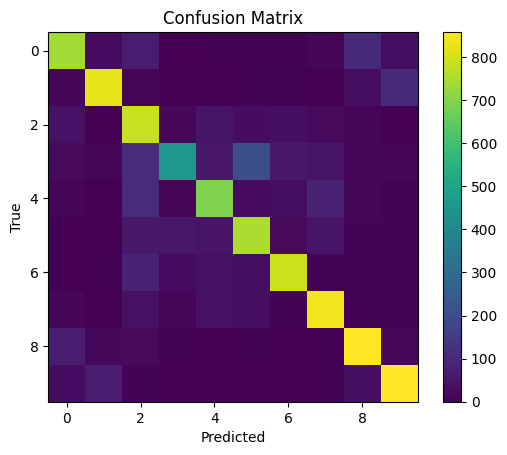

Accuracy: 0.7605
Precision: 0.7661805779001345
Recall: 0.7604999999999998
F1: 0.7575508898215938
              precision    recall  f1-score   support

           0       0.78      0.74      0.76      1000
           1       0.86      0.83      0.84      1000
           2       0.61      0.79      0.68      1000
           3       0.77      0.46      0.58      1000
           4       0.74      0.69      0.72      1000
           5       0.69      0.75      0.72      1000
           6       0.82      0.79      0.81      1000
           7       0.78      0.84      0.81      1000
           8       0.79      0.86      0.82      1000
           9       0.82      0.85      0.84      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000



(ResNet(
   (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
   (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (relu): ReLU(inplace=True)
   (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
   (layer1): Sequential(
     (0): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU(inplace=True)
       (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     )
     (1): BasicBlock(
       (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (relu): ReLU

In [37]:
pipeline(resnet_model, trainloader, valloader,testloader,optimizer, nn.CrossEntropyLoss(), device, 20)

In [38]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, num_classes)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
pipeline(model, trainloader, valloader,testloader,optimizer, nn.CrossEntropyLoss(), device, 20)

Epoch [1/20]: 100%|██████████| 704/704 [02:55<00:00,  4.01it/s, train_loss=0.285]


Epoch 1: Train Loss=0.3863 Val Loss=0.2273 Val Acc=0.9228


Epoch [2/20]:  18%|█▊        | 128/704 [00:30<02:23,  4.02it/s, train_loss=0.159]

In [ ]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

model.fc = nn.Linear(model.fc.in_features, num_classes)

optimizer = torch.optim.Adam([
    {"params": model.layer1.parameters(), "lr": 1e-5},
    {"params": model.layer2.parameters(), "lr": 1e-5},
    {"params": model.layer3.parameters(), "lr": 5e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])

In [ ]:
pipeline(model, trainloader, valloader,testloader,optimizer, nn.CrossEntropyLoss(), device, 20)

In [ ]:
from torchvision.models import vit_b_16, ViT_B_16_Weights
import torch.nn as nn
import torch.optim as optim

model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

# freeze backbone
for param in model.parameters():
    param.requires_grad = False

# train classifier
for param in model.heads.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(model.heads.parameters(), lr=1e-3)

In [ ]:
pipeline(model, trainloader, valloader,testloader,optimizer, nn.CrossEntropyLoss(), device, 20)

In [ ]:
model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [ ]:
pipeline(model, trainloader, valloader,testloader,optimizer, nn.CrossEntropyLoss(), device, 20)

In [ ]:
model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)

optimizer = optim.AdamW([
    {"params": model.conv_proj.parameters(), "lr": 1e-5},
    {"params": model.encoder.layers[:6].parameters(), "lr": 3e-5},
    {"params": model.encoder.layers[6:].parameters(), "lr": 1e-4},
    {"params": model.heads.parameters(), "lr": 3e-4}
], weight_decay=1e-4)

In [ ]:
pipeline(model, trainloader, valloader,testloader,optimizer, nn.CrossEntropyLoss(), device, 20)